In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import KNNImputer
from scipy.stats import zscore
import random

# Set a seed for reproducibility
np.random.seed(42)
random.seed(42)

# Step 1: Data Collection - Generate a Synthetic Dataset (100k+ records)
num_records = 120000 # More than 100k records

# Customer Demographics
customer_ids = np.arange(1, num_records + 1)
age = np.random.randint(18, 70, num_records)
income = np.random.normal(50000, 15000, num_records).round(2)
income[income < 15000] = 15000 # Ensure minimum income
location_options = ['Urban', 'Suburban', 'Rural']
location = np.random.choice(location_options, num_records, p=[0.4, 0.35, 0.25])

# Transaction History
purchase_frequency = np.random.randint(1, 20, num_records)
purchase_amount = np.random.normal(150, 70, num_records).round(2)
purchase_amount[purchase_amount < 10] = 10 # Ensure minimum purchase amount

# Interaction Data
email_opens = np.random.randint(0, 100, num_records)
clicks = np.random.randint(0, 50, num_records)

# Churn Data (introduce some correlation)
# Higher age, lower income, lower purchase frequency might lead to higher churn
churn_probability = (age / 100) * 0.1 + (1 - income / 100000) * 0.2 + (1 - purchase_frequency / 20) * 0.3 + np.random.normal(0, 0.05, num_records)
churn_probability = np.clip(churn_probability, 0.05, 0.95)
churn_status = (np.random.rand(num_records) < churn_probability).astype(int)

# Churn Date (if churned)
churn_date_series = pd.Series(pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365, num_records), unit='D'))
churn_date_series[churn_status == 0] = pd.NaT # Not a Time for non-churned customers

# Create DataFrame
crm_data = pd.DataFrame({
    'CustomerID': customer_ids,
    'Age': age,
    'Income': income,
    'Location': location,
    'PurchaseFrequency': purchase_frequency,
    'PurchaseAmount': purchase_amount,
    'EmailOpens': email_opens,
    'Clicks': clicks,
    'ChurnStatus': churn_status,
    'ChurnDate': churn_date_series # Use the mutable Series here
})

print("Original Dataset Head:")
print(crm_data.head())
print(f"Original Dataset Shape: {crm_data.shape}")

# Add some noise to numerical features
for col in ['Age', 'Income', 'PurchaseFrequency', 'PurchaseAmount', 'EmailOpens', 'Clicks']:
    noise = np.random.normal(0, crm_data[col].std() * 0.05, num_records) # 5% of std as noise
    crm_data[col] = crm_data[col] + noise
    crm_data[col] = crm_data[col].round(2)
    if col in ['Age', 'PurchaseFrequency', 'EmailOpens', 'Clicks']:
        crm_data[col] = crm_data[col].astype(int)


# Step 2: Data Cleaning and Preprocessing

# 1. Handle missing values
# Introduce some missing values artificially for demonstration
missing_values_cols = ['Age', 'Income', 'PurchaseAmount', 'ChurnDate']
for col in missing_values_cols:
    if col == 'ChurnDate': # Introduce NaNs for non-churned customers as part of original data
        continue
    missing_indices = np.random.choice(crm_data.index, size=int(num_records * 0.02), replace=False)
    crm_data.loc[missing_indices, col] = np.nan

print("\nMissing values before handling:")
print(crm_data.isnull().sum())

# Impute numerical missing values using KNNImputer
numerical_cols = ['Age', 'Income', 'PurchaseFrequency', 'PurchaseAmount', 'EmailOpens', 'Clicks']
# Exclude ChurnDate from KNN imputation as it's handled separately
imputer = KNNImputer(n_neighbors=5)
crm_data[numerical_cols] = imputer.fit_transform(crm_data[numerical_cols])

# Fill missing ChurnDate with a placeholder if ChurnStatus is 0 (already handled by NaT during generation)
# Or, if ChurnDate was missing for a churned customer, we might want to impute it.
# For this synthetic data, NaT signifies no churn. No further imputation needed for ChurnDate.

print("\nMissing values after numerical imputation:")
print(crm_data.isnull().sum())

# Ensure numerical columns are back to appropriate types if they were converted to float by imputer
crm_data['Age'] = crm_data['Age'].astype(int)
crm_data['PurchaseFrequency'] = crm_data['PurchaseFrequency'].astype(int)
crm_data['EmailOpens'] = crm_data['EmailOpens'].astype(int)
crm_data['Clicks'] = crm_data['Clicks'].astype(int)

# 2. Data transformation
# Convert categorical variables to numerical variables using One-Hot Encoding for 'Location'
# Label Encoding could also be used depending on the variable's nature
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
location_encoded = one_hot_encoder.fit_transform(crm_data[['Location']])
location_df = pd.DataFrame(location_encoded, columns=one_hot_encoder.get_feature_names_out(['Location']))

crm_data = pd.concat([crm_data.drop('Location', axis=1), location_df], axis=1)

# Scale numerical variables using Standardization (StandardScaler)
scaler = StandardScaler()
crm_data[numerical_cols] = scaler.fit_transform(crm_data[numerical_cols])

print("\nCRM Data Head after One-Hot Encoding and Standardization of numerical columns:")
print(crm_data.head())

# 3. Remove duplicates and outliers
# Identify and remove duplicates
duplicates_before = crm_data.duplicated().sum()
print(f"\nNumber of duplicate rows before removal: {duplicates_before}")
crm_data.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {crm_data.duplicated().sum()}")
print(f"Dataset shape after duplicate removal: {crm_data.shape}")

# Identify outliers using Z-score for numerical columns
print("\nIdentifying outliers using Z-score:")
outlier_threshold = 3
for col in numerical_cols:
    # Recalculate Z-score after imputation and scaling
    z_scores = np.abs(zscore(crm_data[col]))
    outliers = crm_data[z_scores > outlier_threshold]
    print(f"Column '{col}': {len(outliers)} outliers found (Z-score > {outlier_threshold})")
    # Note: For demonstration, we just identify. Removal or transformation would depend on context.

print("\nData Preprocessing Complete.")
print(crm_data.head())
print(f"Final Dataset Shape: {crm_data.shape}")

Original Dataset Head:
   CustomerID  Age    Income  Location  PurchaseFrequency  PurchaseAmount  \
0           1   56  47831.90     Rural                  7          151.76   
1           2   69  48251.78     Urban                  3          114.43   
2           3   46  62155.00     Urban                 18           85.64   
3           4   32  74958.50     Rural                 16           46.66   
4           5   60  79496.53  Suburban                  6           97.29   

   EmailOpens  Clicks  ChurnStatus  ChurnDate  
0          76      38            1 2023-04-22  
1          64      37            1 2023-01-02  
2          30      16            1 2023-07-23  
3          18      43            0        NaT  
4          83      31            1 2023-02-06  
Original Dataset Shape: (120000, 10)

Missing values before handling:
CustomerID               0
Age                   2400
Income                2400
Location                 0
PurchaseFrequency        0
PurchaseAmount       

### 📊 Exploratory Data Analysis (EDA): Visualizing Data Distributions

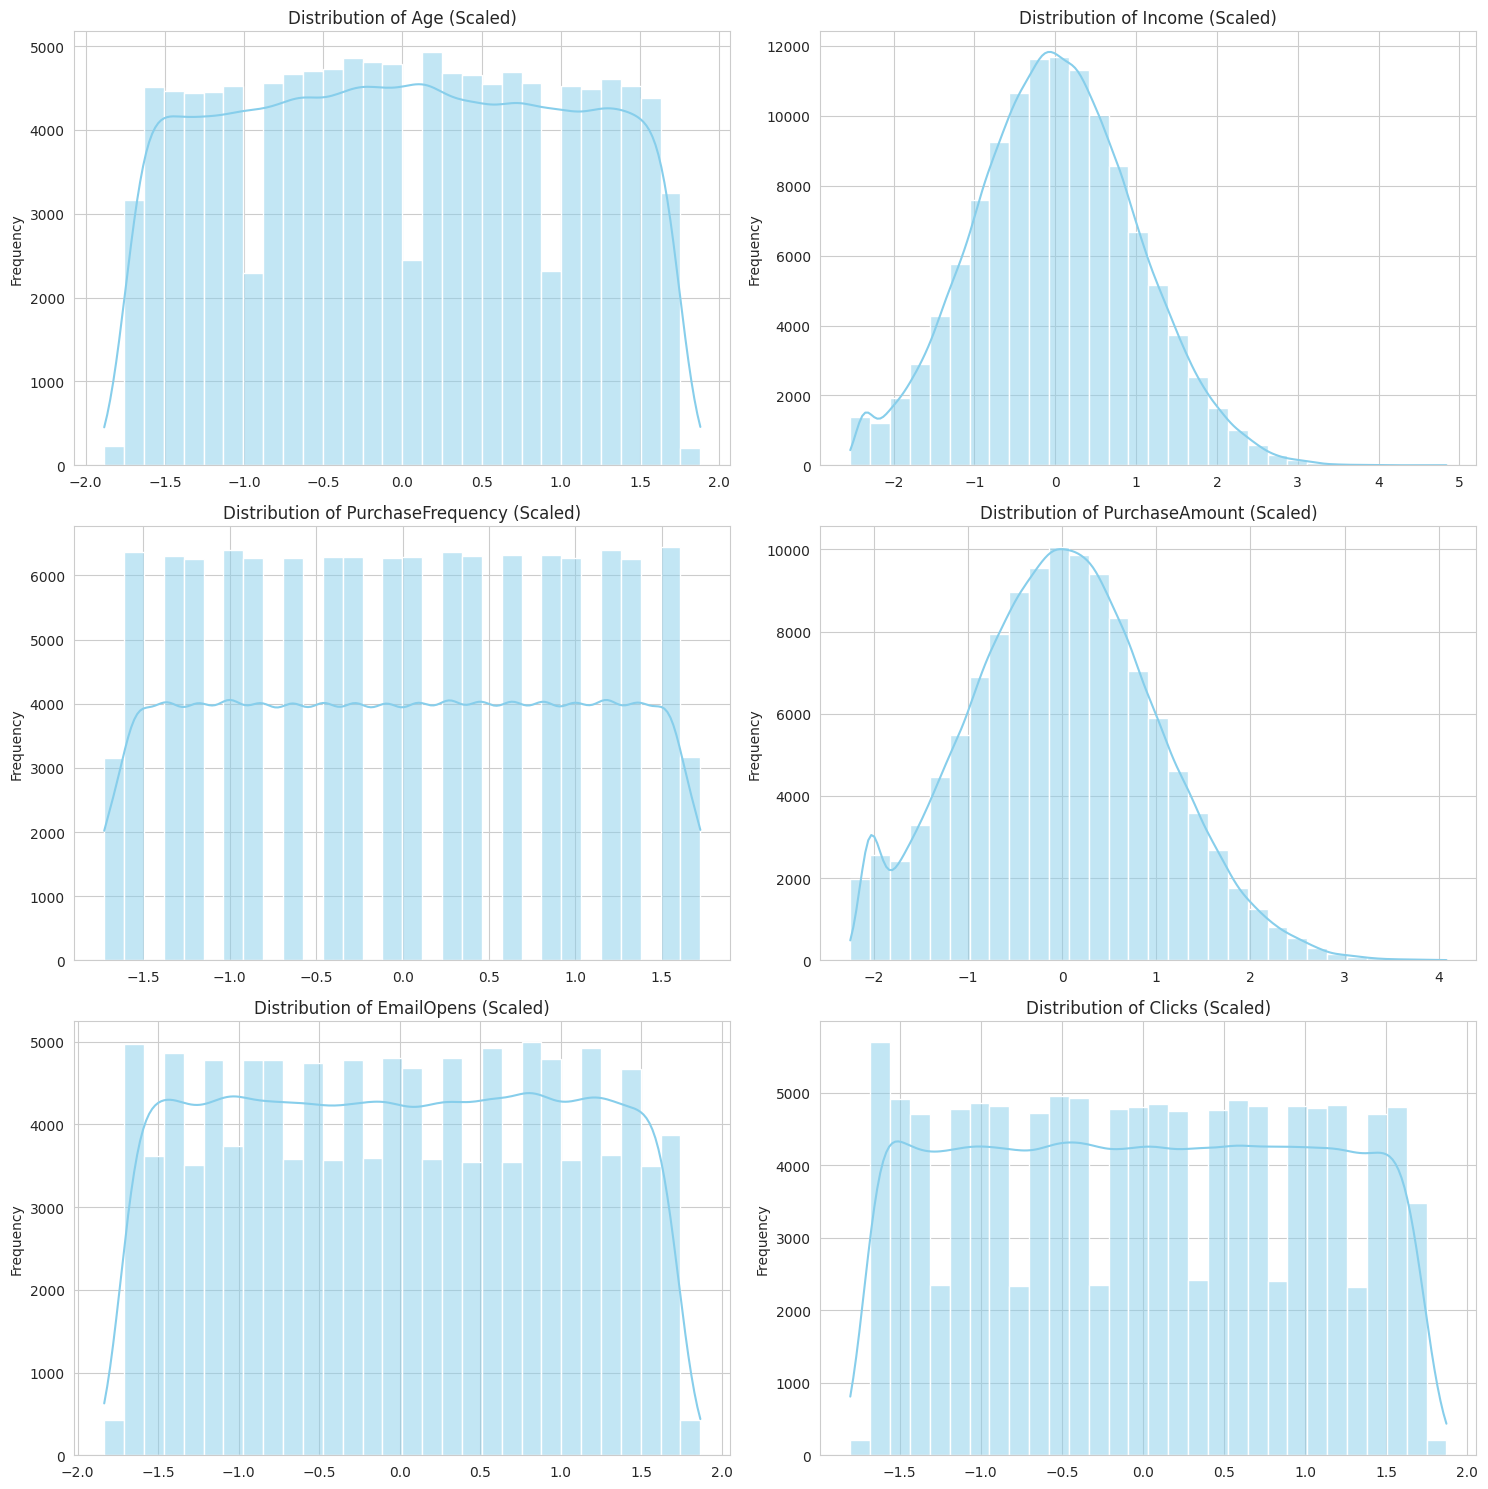

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# Plotting distributions of numerical features
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()
numerical_cols = ['Age', 'Income', 'PurchaseFrequency', 'PurchaseAmount', 'EmailOpens', 'Clicks']

for i, col in enumerate(numerical_cols):
    sns.histplot(crm_data[col], kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(f'Distribution of {col} (Scaled)')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 📊 EDA: Churn Status and Location Distribution

/tmp/ipykernel_10306/3700959851.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ChurnStatus', data=crm_data, ax=axes[0], palette='viridis')
/tmp/ipykernel_10306/3700959851.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.index, y=location_counts.values, ax=axes[1], palette='magma')


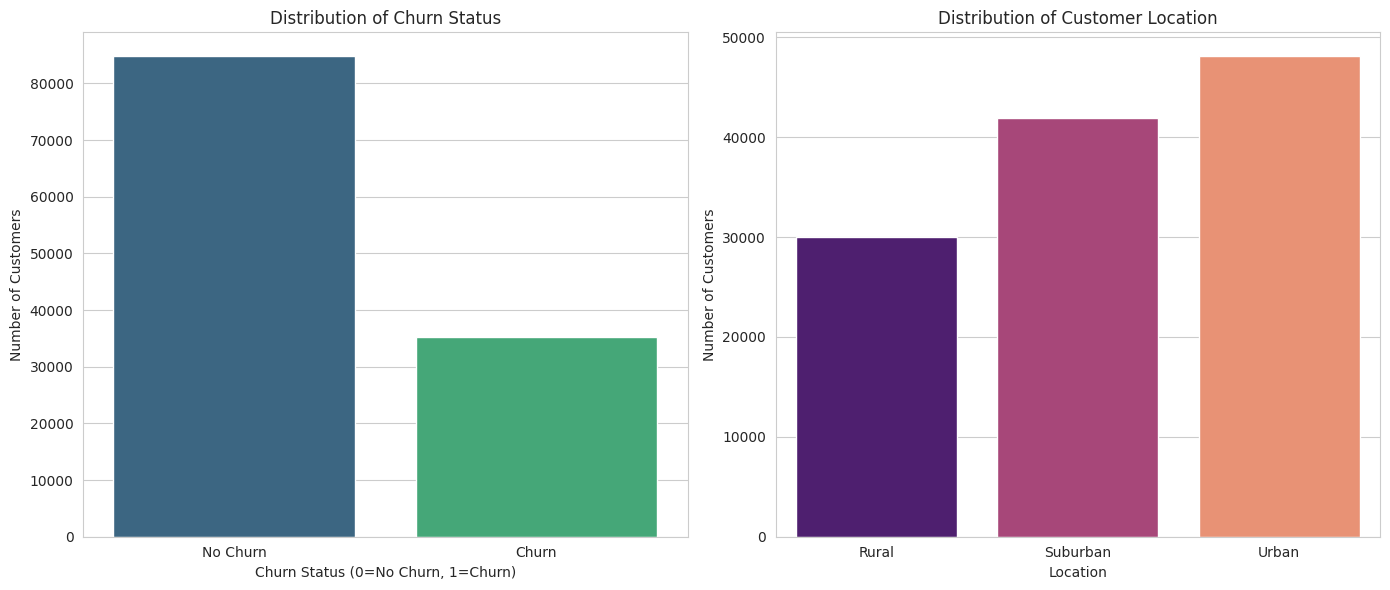

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Churn Status distribution
sns.countplot(x='ChurnStatus', data=crm_data, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Churn Status')
axes[0].set_xlabel('Churn Status (0=No Churn, 1=Churn)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Churn', 'Churn'])

# Location distribution (from one-hot encoded columns)
location_cols = [col for col in crm_data.columns if col.startswith('Location_')]
location_counts = crm_data[location_cols].sum()
location_counts.index = [col.replace('Location_', '') for col in location_counts.index]
sns.barplot(x=location_counts.index, y=location_counts.values, ax=axes[1], palette='magma')
axes[1].set_title('Distribution of Customer Location')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### 📊 EDA: Relationships between Numerical Features (Correlation Heatmap)

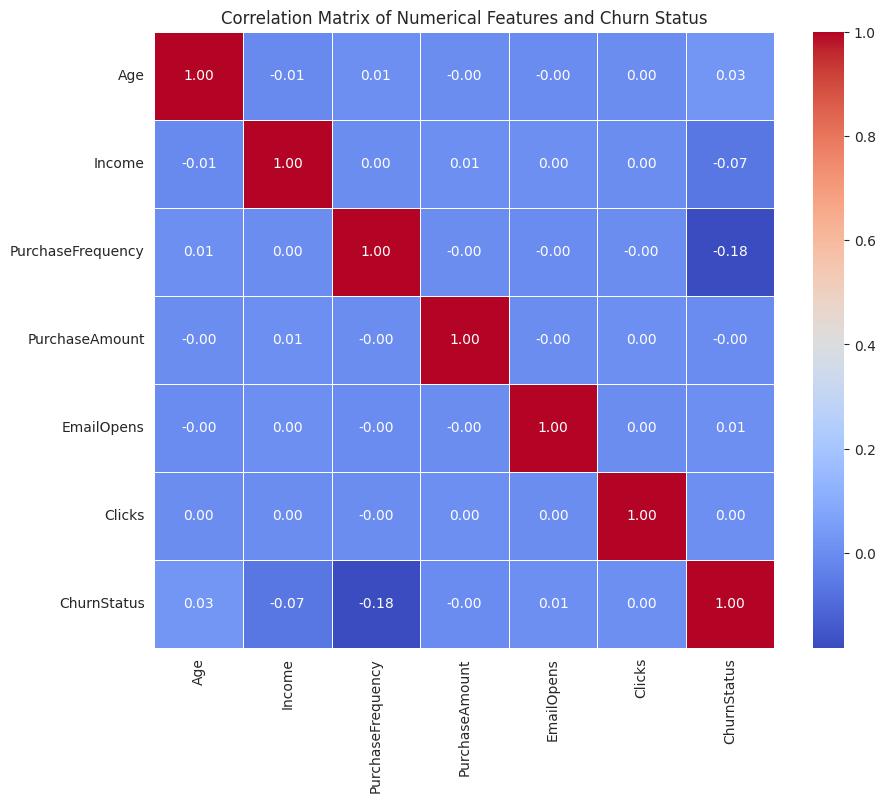

In [20]:
plt.figure(figsize=(10, 8))
correlation_matrix = crm_data[numerical_cols + ['ChurnStatus']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features and Churn Status')
plt.show()

### 📊 EDA: Numerical Feature Comparison by Churn Status

### 📊 Statistical Analysis: Logistic Regression for Churn Factors

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import statsmodels.api as sm

print("\n--- Logistic Regression for Churn Factors ---")

# Define features (X) and target (y)
# Exclude 'CustomerID' and 'ChurnDate' (as it contains NaT values and is outcome-related)
features = [col for col in crm_data.columns if col not in ['CustomerID', 'ChurnStatus', 'ChurnDate']]
X = crm_data[features]
y = crm_data['ChurnStatus']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize and train the Logistic Regression model
# Using liblinear solver for smaller datasets and for handling L1/L2 penalties
logistic_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Evaluate the model
print(f"\nLogistic Regression Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Interpret coefficients using statsmodels for more detailed statistical output
# Add a constant term for intercept
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit(disp=False) # disp=False to suppress iteration details

print("\nLogistic Regression Coefficients and P-values (using Statsmodels):")
print(result.summary())

print("\nKey factors influencing churn based on coefficients (absolute magnitude, higher implies stronger influence):\n")
# Extract coefficients and sort by absolute value to see most influential factors
coefs_df = pd.DataFrame({
    'Feature': result.params.index,
    'Coefficient': result.params.values,
    'P-value': result.pvalues.values
})
coefs_df = coefs_df.sort_values(by='Coefficient', ascending=False)
print(coefs_df)



--- Logistic Regression for Churn Factors ---

Logistic Regression Model Accuracy: 0.7064

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83     25436
           1       0.49      0.01      0.02     10564

    accuracy                           0.71     36000
   macro avg       0.60      0.50      0.42     36000
weighted avg       0.64      0.71      0.59     36000


Logistic Regression Coefficients and P-values (using Statsmodels):
                           Logit Regression Results                           
Dep. Variable:            ChurnStatus   No. Observations:                84000
Model:                          Logit   Df Residuals:                    83991
Method:                           MLE   Df Model:                            8
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                 0.03182
Time:                        06:10:26   Log-Likelihood:                -49221.
converged:      

### 📊 Statistical Analysis: K-Means Clustering for Customer Segmentation


--- K-Means Clustering for Customer Segmentation ---


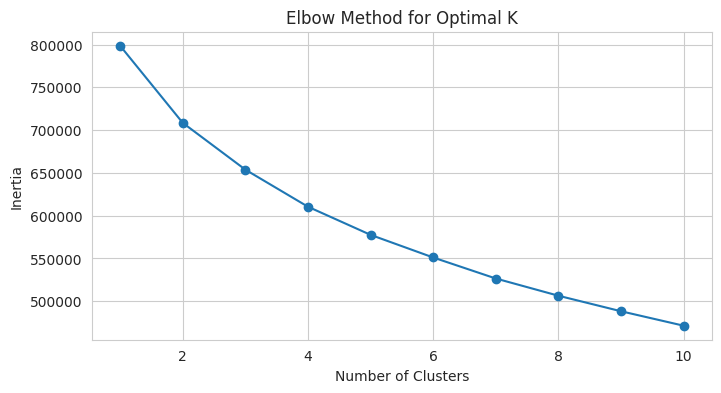


K-Means Clustering with 3 clusters:
Cluster
2    44872
0    37881
1    37247
Name: count, dtype: int64

Calculating Silhouette Score on a sample of 10000 records...
Silhouette Score: 0.0976
Calinski-Harabasz Index: 13292.7657


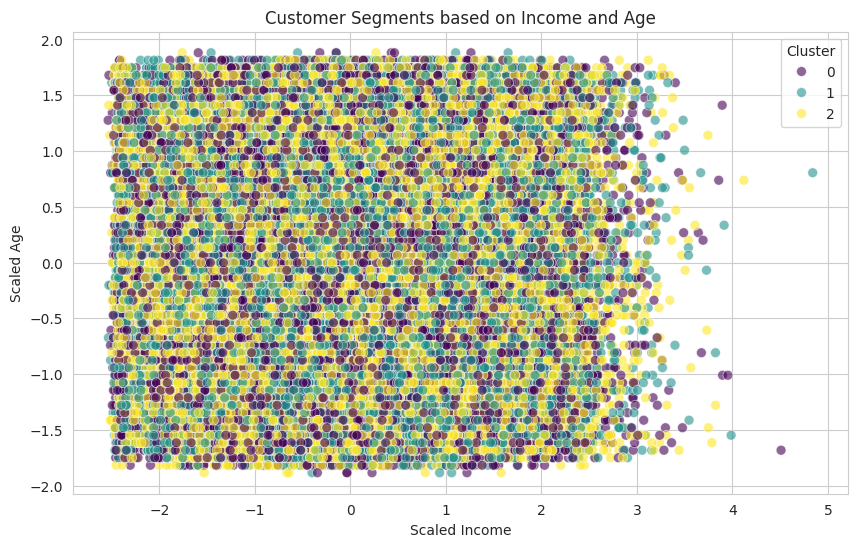

/tmp/ipykernel_10306/4033493022.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='PurchaseAmount', data=crm_data, palette='viridis')


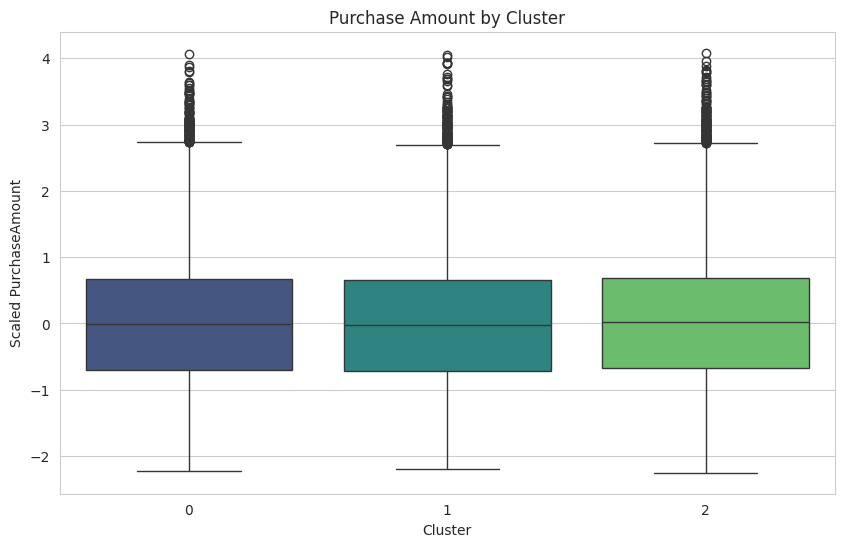


--- Cluster Characteristics ---
              Age    Income  PurchaseFrequency  PurchaseAmount  EmailOpens  \
Cluster                                                                      
0       -0.003044 -0.005075           0.928852       -0.007675   -0.010274   
1       -0.008066 -0.004866          -0.932806       -0.017498   -0.002724   
2        0.009265  0.008323          -0.009841        0.021004    0.010934   

           Clicks  ChurnStatus  
Cluster                         
0       -0.624938     0.214461  
1       -0.634671     0.371815  
2        1.054396     0.295106  
         Location_Urban  Location_Suburban  Location_Rural
Cluster                                                   
0              0.404028           0.349912        0.246060
1              0.402878           0.349719        0.247402
2              0.396305           0.348748        0.254947


In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

print("\n--- K-Means Clustering for Customer Segmentation ---")

# Features for clustering (same as for logistic regression, excluding ChurnStatus)
# We use the scaled features from crm_data
X_cluster = crm_data[features].copy()

# Determine the optimal number of clusters (e.g., using Elbow method or Silhouette score)
# For demonstration, let's try a range of clusters and calculate Silhouette Score
# This might take some time for 120k records if many clusters are tried.
# Let's fix k for now to 3 or 4 for efficiency in this demonstration.

# Elbow Method (Optional - for finding optimal k)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Let's choose 3 clusters for demonstration based on common practice or hypothetical Elbow point
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init is important for robustness
crm_data['Cluster'] = kmeans.fit_predict(X_cluster)

print(f"\nK-Means Clustering with {n_clusters} clusters:")
print(crm_data['Cluster'].value_counts())

# Evaluate cluster quality
# Silhouette Score: measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation).
# Range from -1 (poor clustering) to +1 (dense clustering). 0 indicates overlapping clusters.
# Calinski-Harabasz Index: a ratio of the sum of between-clusters dispersion and of within-cluster dispersion.
# Higher value generally indicates better clustering.

# Sampling for Silhouette Score due to large dataset size
# Calculating Silhouette Score on 120k data points can be very slow and memory intensive
# Sample a subset if performance is an issue.
if len(X_cluster) > 10000:
    sample_size = 10000
    X_sample, _, y_cluster_sample, _ = train_test_split(X_cluster, crm_data['Cluster'], test_size=(len(X_cluster) - sample_size) / len(X_cluster), random_state=42, stratify=crm_data['Cluster'])
    print(f"\nCalculating Silhouette Score on a sample of {sample_size} records...")
    silhouette_avg = silhouette_score(X_sample, y_cluster_sample)
else:
    silhouette_avg = silhouette_score(X_cluster, crm_data['Cluster'])

calinski_harabasz_index = calinski_harabasz_score(X_cluster, crm_data['Cluster'])

print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_index:.4f}")

# Visualize clusters (e.g., using a pairplot or t-SNE/PCA for dimensionality reduction)
# For simplicity, let's visualize a few features against clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Age', hue='Cluster', data=crm_data, palette='viridis', s=50, alpha=0.6)
plt.title('Customer Segments based on Income and Age')
plt.xlabel('Scaled Income')
plt.ylabel('Scaled Age')
plt.legend(title='Cluster')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='PurchaseAmount', data=crm_data, palette='viridis')
plt.title('Purchase Amount by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Scaled PurchaseAmount')
plt.show()

print("\n--- Cluster Characteristics ---")
# Analyze the characteristics of each cluster
cluster_summary = crm_data.groupby('Cluster')[numerical_cols + ['ChurnStatus']].mean()
print(cluster_summary)

# For categorical features (Location)
location_cluster_dist = crm_data.groupby('Cluster')[['Location_Urban', 'Location_Suburban', 'Location_Rural']].mean()
print(location_cluster_dist)


### 📊 Statistical Analysis: Survival Analysis for Customer Lifetime Value (CLV)

ERROR: Could not find a version that satisfies the requirement lifestyle (from versions: none)
ERROR: No matching distribution found for lifestyle

--- Survival Analysis for Customer Lifetime Value (CLV) ---

Kaplan-Meier Survival Function Summary:
          KM_estimate
timeline             
0.0          0.999250
1.0          0.998292
2.0          0.997600
3.0          0.996750
4.0          0.995983


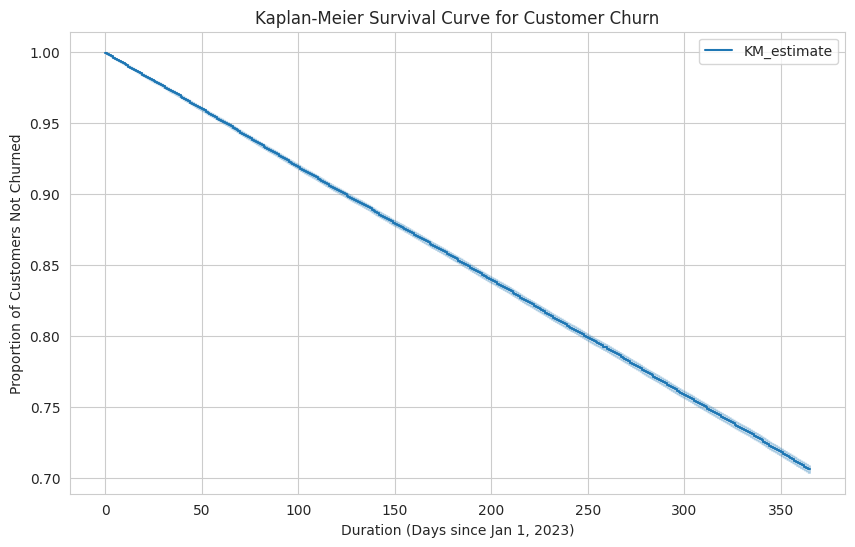


Median Survival Time: inf days


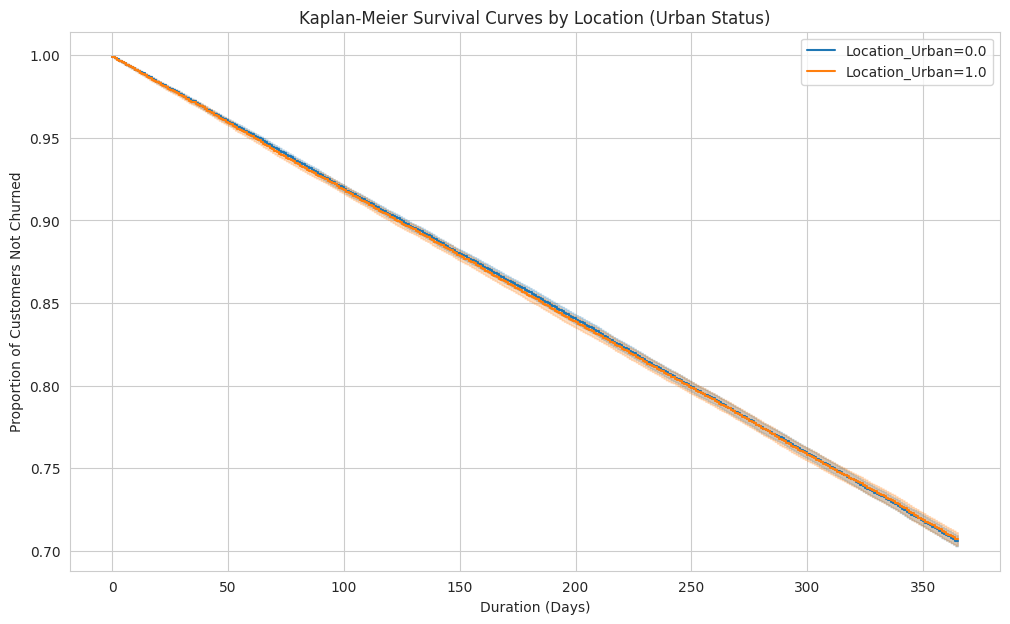

In [24]:
! pip install lifestyle
import datetime
from lifelines import KaplanMeierFitter
from lifelines.utils import datetimes_to_durations

print("\n--- Survival Analysis for Customer Lifetime Value (CLV) ---")

# For Survival Analysis, we need duration and event (churn) status.
# We already have 'ChurnStatus' (event=1 if churned, 0 if not).
# We need to calculate 'duration' (time until churn or end of observation).

# Define an observation end date
observation_end_date = pd.to_datetime('2024-01-01')

# For non-churned customers, the duration is the time from start of observation to observation_end_date.
# For churned customers, the duration is the time from start of observation to ChurnDate.

# Assuming all customers started at the same hypothetical 'start_date' for simplicity
# In a real scenario, this would be their acquisition date.
start_date = pd.to_datetime('2023-01-01')

# Calculate duration for each customer
# If ChurnDate is NaT (not churned), duration is until observation_end_date
# If ChurnDate is present (churned), duration is until ChurnDate

crm_data['ObservationEndDate'] = observation_end_date

crm_data['Duration'] = (crm_data['ChurnDate'].fillna(crm_data['ObservationEndDate']) - start_date).dt.days

# The event observed is 'ChurnStatus'
# 'Duration' is in days

# Initialize the KaplanMeierFitter
kmf = KaplanMeierFitter()

# Fit the data
kmf.fit(crm_data['Duration'], event_observed=crm_data['ChurnStatus'])

print("\nKaplan-Meier Survival Function Summary:")
print(kmf.survival_function_.head())

# Plot the survival function
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve for Customer Churn')
plt.xlabel('Duration (Days since Jan 1, 2023)')
plt.ylabel('Proportion of Customers Not Churned')
plt.grid(True)
plt.show()

# Example of median survival time
print(f"\nMedian Survival Time: {kmf.median_survival_time_} days")

# You can also segment the survival curves by a variable, e.g., 'Location'
plt.figure(figsize=(12, 7))
for name, data in crm_data.groupby('Location_Urban'): # Using one of the one-hot encoded location cols for grouping
    kmf.fit(data['Duration'], event_observed=data['ChurnStatus'], label=f'Location_Urban={name}')
    kmf.plot_survival_function()

plt.title('Kaplan-Meier Survival Curves by Location (Urban Status)')
plt.xlabel('Duration (Days)')
plt.ylabel('Proportion of Customers Not Churned')
plt.grid(True)
plt.show()


### 📊 Statistical Analysis: ANOVA for Marketing Campaign Effectiveness


--- ANOVA for Marketing Campaign Effectiveness ---

ANOVA F-statistic for PurchaseAmount across Marketing Campaigns: 0.2536
ANOVA P-value for PurchaseAmount across Marketing Campaigns: 0.7760
Conclusion: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in mean PurchaseAmount between the marketing campaigns.


/tmp/ipykernel_10306/2988473999.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MarketingCampaign', y='PurchaseAmount', data=crm_data, palette='coolwarm')


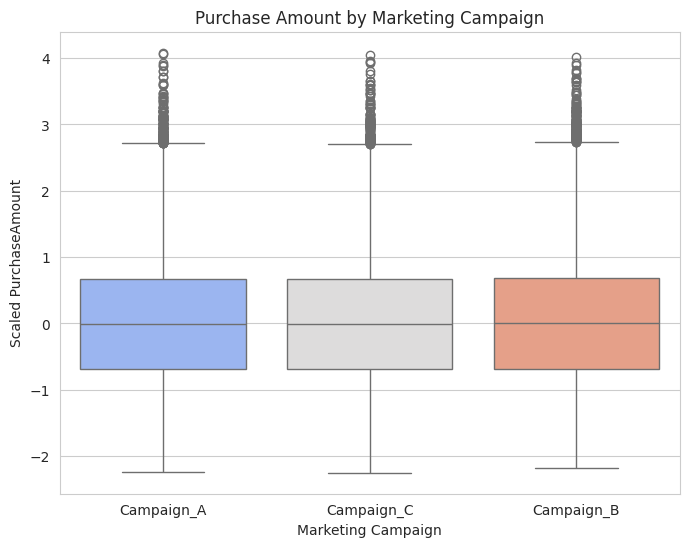

In [25]:
from scipy.stats import f_oneway

print("\n--- ANOVA for Marketing Campaign Effectiveness ---")

# For demonstration, let's create a hypothetical 'MarketingCampaign' column
# and analyze its effect on 'PurchaseAmount'.
# Assume 3 types of marketing campaigns (A, B, C) randomly assigned.

crm_data['MarketingCampaign'] = np.random.choice(['Campaign_A', 'Campaign_B', 'Campaign_C'], size=len(crm_data))

# Perform ANOVA to compare 'PurchaseAmount' across different campaigns

campaign_a_purchases = crm_data[crm_data['MarketingCampaign'] == 'Campaign_A']['PurchaseAmount']
campaign_b_purchases = crm_data[crm_data['MarketingCampaign'] == 'Campaign_B']['PurchaseAmount']
campaign_c_purchases = crm_data[crm_data['MarketingCampaign'] == 'Campaign_C']['PurchaseAmount']

f_statistic, p_value = f_oneway(campaign_a_purchases, campaign_b_purchases, campaign_c_purchases)

print(f"\nANOVA F-statistic for PurchaseAmount across Marketing Campaigns: {f_statistic:.4f}")
print(f"ANOVA P-value for PurchaseAmount across Marketing Campaigns: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in mean PurchaseAmount between at least two of the marketing campaigns.")
    # Further analysis (e.g., Tukey's HSD post-hoc test) would be needed to determine which specific campaigns differ.
else:
    print("Conclusion: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in mean PurchaseAmount between the marketing campaigns.")

# Visualize the difference with a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='MarketingCampaign', y='PurchaseAmount', data=crm_data, palette='coolwarm')
plt.title('Purchase Amount by Marketing Campaign')
plt.xlabel('Marketing Campaign')
plt.ylabel('Scaled PurchaseAmount')
plt.show()


### 📈 Machine Learning: Random Forest Classifier for Churn Prediction


--- Random Forest Classifier for Churn Prediction ---

Random Forest Model Accuracy: 0.6995
Random Forest Model Precision: 0.4047
Random Forest Model Recall: 0.0510
Random Forest Model F1-Score: 0.0906
Random Forest Model ROC AUC Score: 0.5868

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.97      0.82     25436
           1       0.40      0.05      0.09     10564

    accuracy                           0.70     36000
   macro avg       0.56      0.51      0.46     36000
weighted avg       0.62      0.70      0.61     36000


Top 10 Random Forest Feature Importances:
Income               0.205651
PurchaseAmount       0.198754
EmailOpens           0.165472
Clicks               0.147925
Age                  0.140718
PurchaseFrequency    0.099299
Location_Urban       0.014756
Location_Suburban    0.014379
Location_Rural       0.013045
dtype: float64


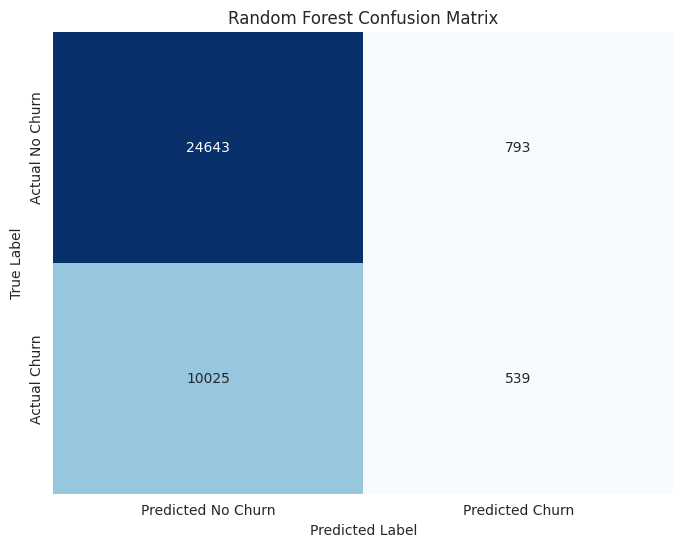

/tmp/ipykernel_10306/3941492723.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_rf.head(10).values, y=feature_importances_rf.head(10).index, palette='viridis')


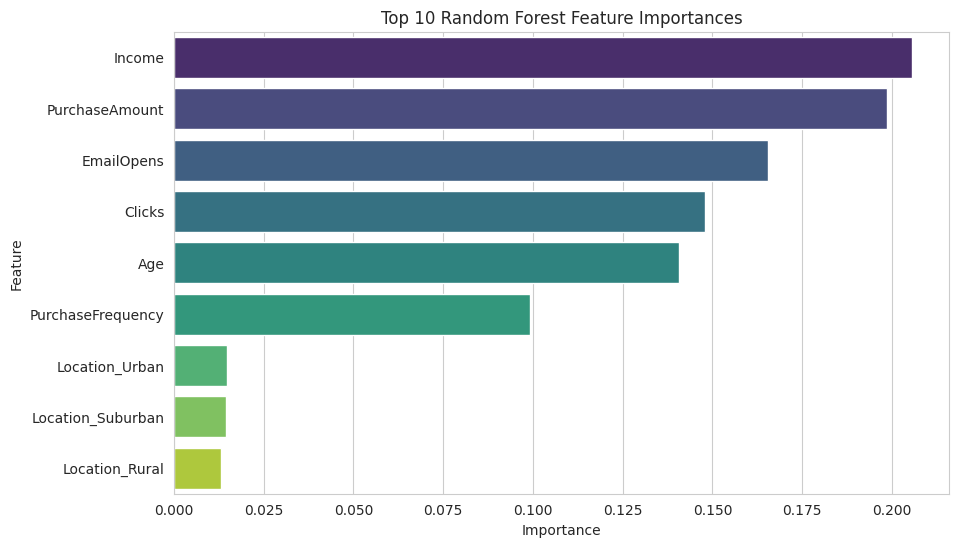

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Random Forest Classifier for Churn Prediction ---")

# Define features (X) and target (y)
# Use the same X and y from Logistic Regression, excluding ChurnDate
# Ensure 'MarketingCampaign' is dropped if it was only for ANOVA demonstration
X_ml = crm_data[[col for col in crm_data.columns if col not in ['CustomerID', 'ChurnStatus', 'ChurnDate', 'Duration', 'ObservationEndDate', 'MarketingCampaign', 'Cluster']]]
y_ml = crm_data['ChurnStatus']

# Split data into training and testing sets
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_ml, y_ml, test_size=0.3, random_state=42, stratify=y_ml)

# Initialize and train the Random Forest Classifier
# Using a reasonable number of estimators and controlling for class imbalance
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1) # n_jobs=-1 to use all available cores
rf_classifier.fit(X_train_ml, y_train_ml)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test_ml)
y_pred_proba_rf = rf_classifier.predict_proba(X_test_ml)[:, 1]

# Evaluate model performance
print(f"\nRandom Forest Model Accuracy: {accuracy_score(y_test_ml, y_pred_rf):.4f}")
print(f"Random Forest Model Precision: {precision_score(y_test_ml, y_pred_rf):.4f}")
print(f"Random Forest Model Recall: {recall_score(y_test_ml, y_pred_rf):.4f}")
print(f"Random Forest Model F1-Score: {f1_score(y_test_ml, y_pred_rf):.4f}")
print(f"Random Forest Model ROC AUC Score: {roc_auc_score(y_test_ml, y_pred_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_ml, y_pred_rf))

# Feature Importance
feature_importances_rf = pd.Series(rf_classifier.feature_importances_, index=X_ml.columns).sort_values(ascending=False)
print("\nTop 10 Random Forest Feature Importances:")
print(feature_importances_rf.head(10))

# Plot Confusion Matrix
cm_rf = confusion_matrix(y_test_ml, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_rf.head(10).values, y=feature_importances_rf.head(10).index, palette='viridis')
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


### 📈 Machine Learning: Decision Tree Classifier for Churn Prediction


--- Decision Tree Classifier for Churn Prediction ---

Decision Tree Model Accuracy: 0.5893
Decision Tree Model Precision: 0.3727
Decision Tree Model Recall: 0.5849
Decision Tree Model F1-Score: 0.4553
Decision Tree Model ROC AUC Score: 0.6182

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.59      0.67     25436
           1       0.37      0.58      0.46     10564

    accuracy                           0.59     36000
   macro avg       0.57      0.59      0.56     36000
weighted avg       0.66      0.59      0.61     36000


Top 10 Decision Tree Feature Importances:
PurchaseFrequency    0.817598
Income               0.153246
Age                  0.025560
PurchaseAmount       0.003595
EmailOpens           0.000000
Clicks               0.000000
Location_Rural       0.000000
Location_Suburban    0.000000
Location_Urban       0.000000
dtype: float64


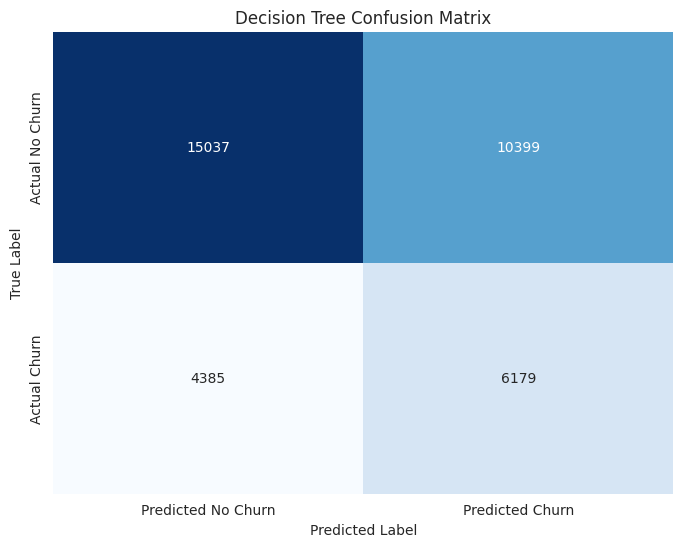

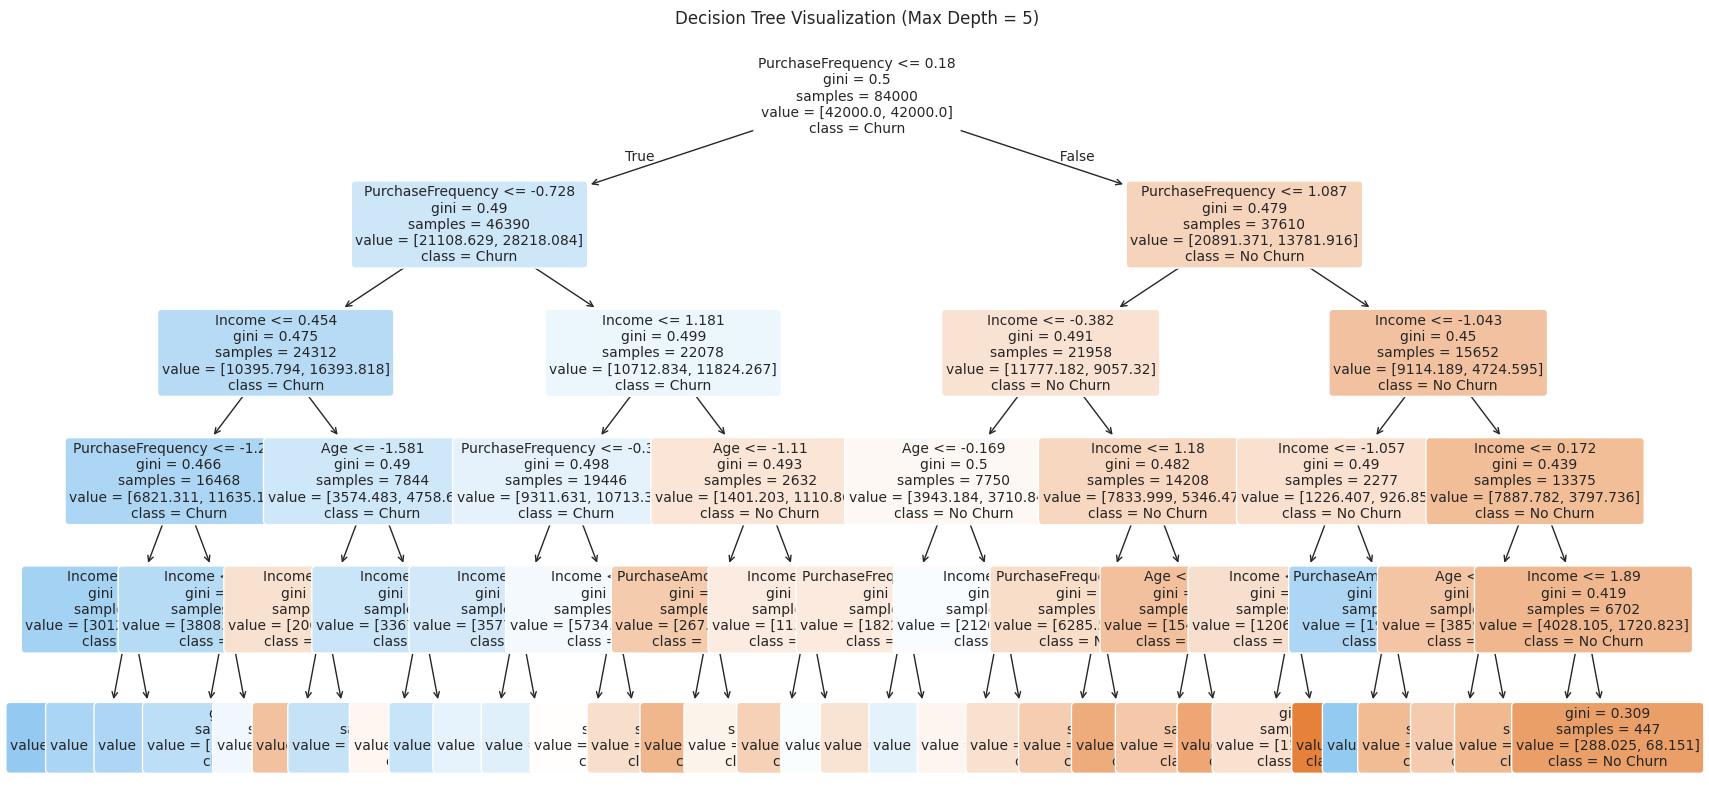

In [28]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

print("\n--- Decision Tree Classifier for Churn Prediction ---")

# Initialize and train the Decision Tree Classifier
# Setting max_depth to avoid overfitting and make the tree interpretable
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
dt_classifier.fit(X_train_ml, y_train_ml)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test_ml)
y_pred_proba_dt = dt_classifier.predict_proba(X_test_ml)[:, 1]

# Evaluate model performance
print(f"\nDecision Tree Model Accuracy: {accuracy_score(y_test_ml, y_pred_dt):.4f}")
print(f"Decision Tree Model Precision: {precision_score(y_test_ml, y_pred_dt):.4f}")
print(f"Decision Tree Model Recall: {recall_score(y_test_ml, y_pred_dt):.4f}")
print(f"Decision Tree Model F1-Score: {f1_score(y_test_ml, y_pred_dt):.4f}")
print(f"Decision Tree Model ROC AUC Score: {roc_auc_score(y_test_ml, y_pred_proba_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_ml, y_pred_dt))

# Feature Importance
feature_importances_dt = pd.Series(dt_classifier.feature_importances_, index=X_ml.columns).sort_values(ascending=False)
print("\nTop 10 Decision Tree Feature Importances:")
print(feature_importances_dt.head(10))

# Plot Confusion Matrix
cm_dt = confusion_matrix(y_test_ml, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualize the Decision Tree (optional, for smaller trees)
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, feature_names=X_ml.columns, class_names=['No Churn', 'Churn'], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization (Max Depth = 5)')
plt.show()


/tmp/ipykernel_10306/3103226571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ChurnStatus', y=col, data=crm_data, ax=axes[i], palette='pastel')
/tmp/ipykernel_10306/3103226571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ChurnStatus', y=col, data=crm_data, ax=axes[i], palette='pastel')
/tmp/ipykernel_10306/3103226571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ChurnStatus', y=col, data=crm_data, ax=axes[i], palette='pastel')
/tmp/ipykernel_10306/3103226571.py:5: FutureWarning: 

Passing `palette` without assigni

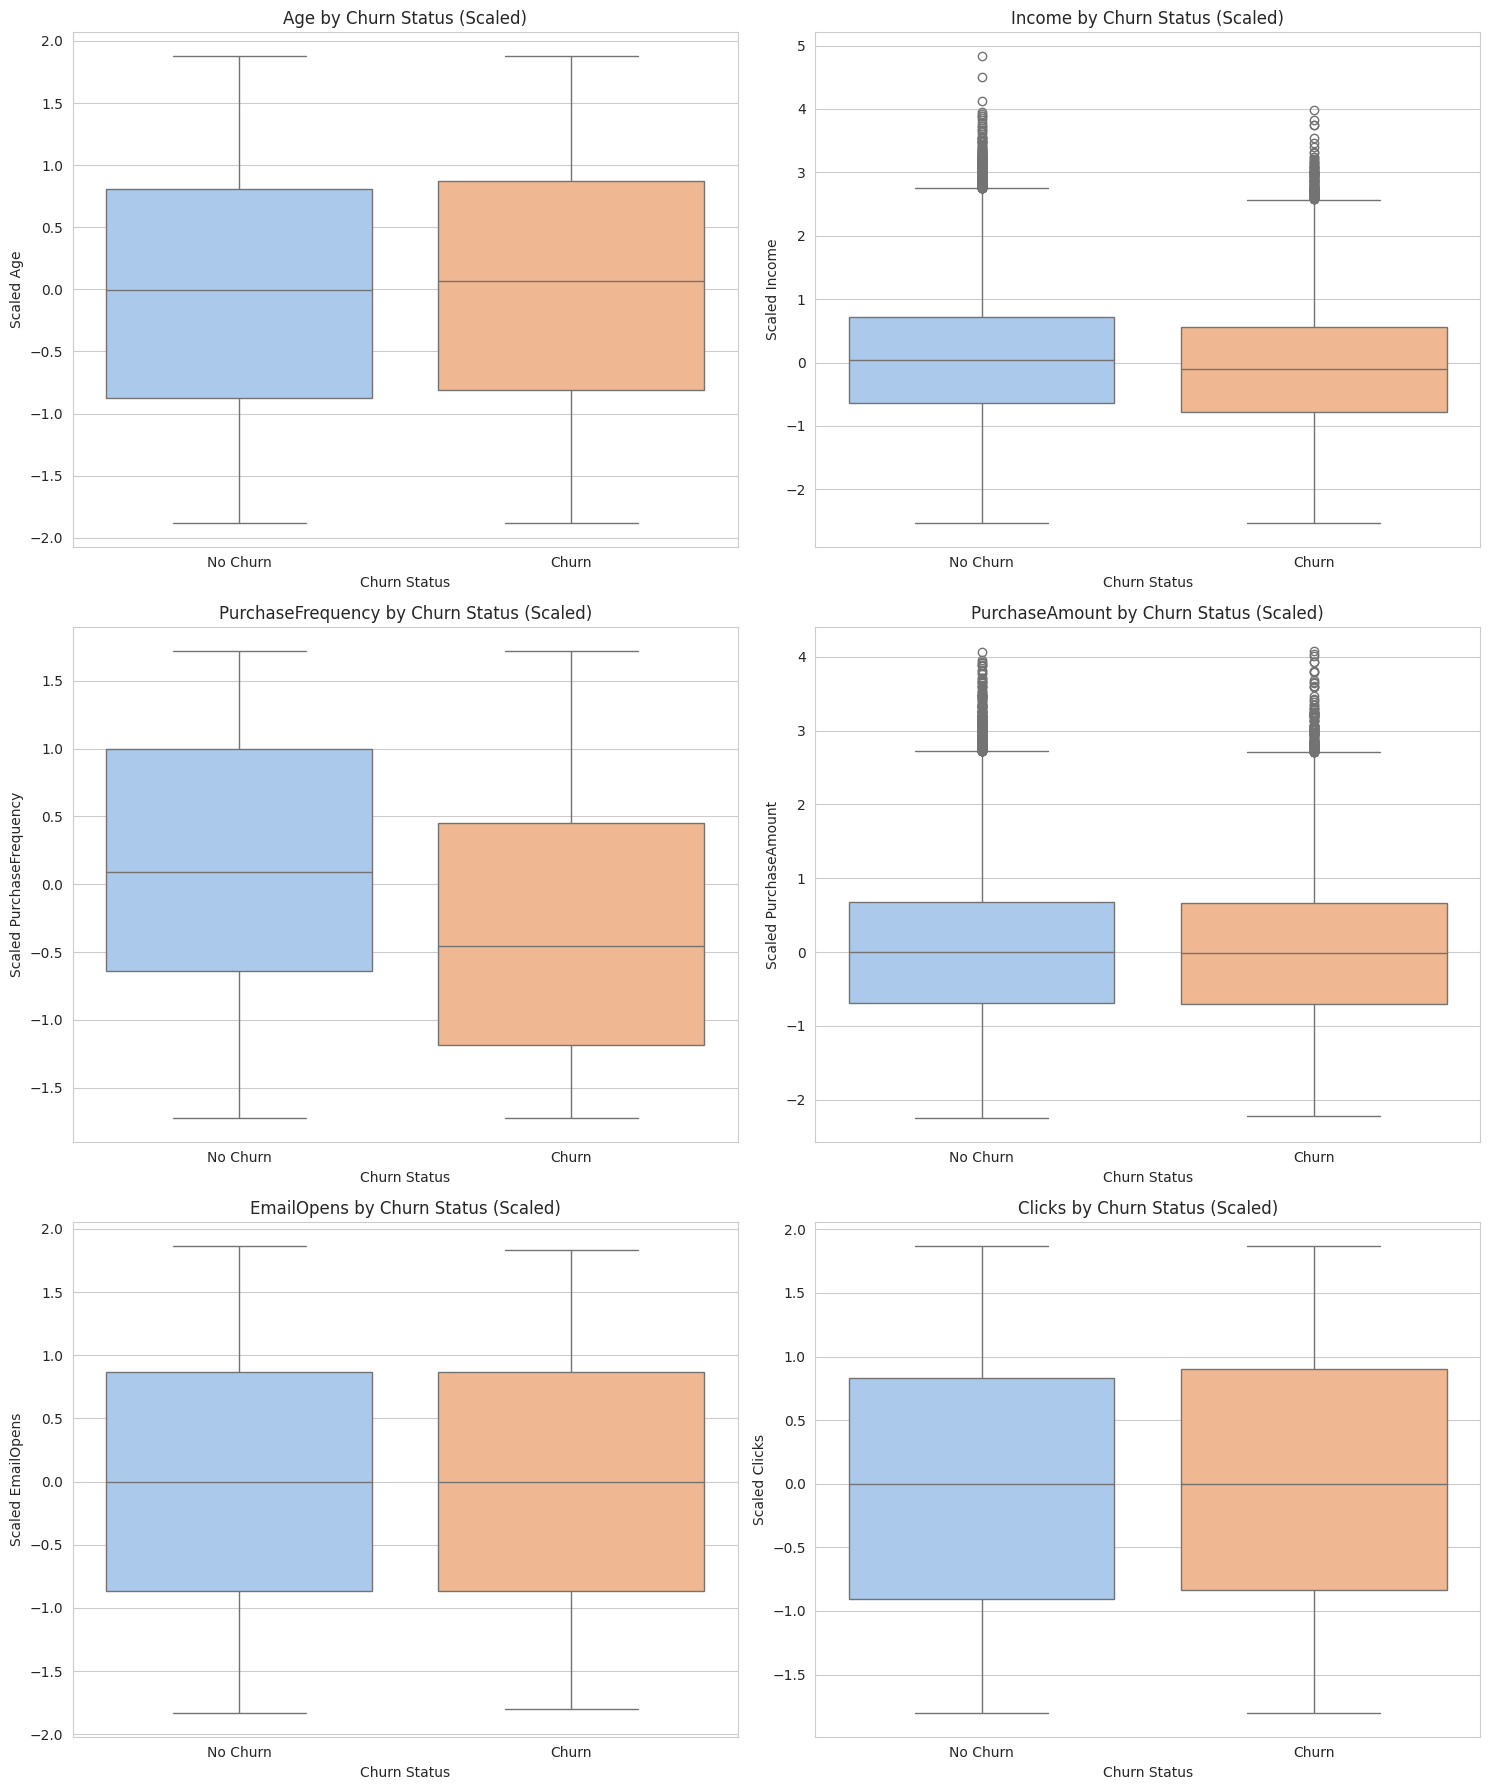

In [29]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='ChurnStatus', y=col, data=crm_data, ax=axes[i], palette='pastel')
    axes[i].set_title(f'{col} by Churn Status (Scaled)')
    axes[i].set_xlabel('Churn Status')
    axes[i].set_ylabel(f'Scaled {col}')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()